# Fault Detection v2 — Multi-Class Model
### SIH 2026 / DRDO Problem Statement 26054

**Dataset:** `MALE_UAV_aero_piston_engine_final_100k.csv`

This is a big upgrade from the first fault-detection notebook. That one only had
one fault type (`injector_degradation`) across 5 missions, so it was a binary
detector. **This dataset has 100 missions and 5 distinct fault types**, so this
notebook builds a real **multi-class** fault classifier — it doesn't just say
"something's wrong," it says *which specific fault* is happening.

| mission_type | # missions | maps to fault_type |
|---|---|---|
| normal_isr, high_altitude, hot_weather, endurance, rapid_throttle | 70 total | `normal` (these are normal operational/environmental variations, not faults) |
| injector_degradation | 10 | `injector_degradation` |
| lubrication_degradation | 8 | `lubrication_degradation` |
| overheating | 5 | `overheating` |
| misfire | 4 | `misfire` |
| sensor_fault | 3 | `sensor_fault` |

Each fault-type mission starts normal and the fault ramps up in severity partway
through — same pattern as before, just now across many missions per fault
instead of one.

**How the model works, in plain terms:** at every 1-second timestep, we compute
~55 features from the raw sensors (rolling averages, rolling volatility, trends,
and how far actual readings deviate from the physics model's expected values).
We feed these into an **XGBoost multi-class classifier** — a tree-based model
that learns, from thousands of labeled examples, which combinations of feature
values are characteristic of each fault type. It outputs a probability for each
of the 6 classes (`normal` + 5 faults) per timestep; we take the highest one as
the prediction.

**Pipeline:** Load → EDA → Feature engineering → Mission-level stratified split
→ Multi-class XGBoost → Evaluation (per-class precision/recall, confusion
matrix, ROC-AUC) → SHAP explainability → Combined fault-output function →
Save model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import joblib
import json

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load and inspect the data

In [2]:
df = pd.read_csv('MALE_UAV_aero_piston_engine_final_100k.csv')
df = df.sort_values(['mission_id', 'timestamp_s']).reset_index(drop=True)

print(df.shape)
df.head()


(100000, 34)


,timestamp_s,engine_id,mission_id,mission_type,altitude_m,ambient_temp_C,pressure_kPa,air_density_kg_m3,throttle_pct,load_pct,rpm,air_mass_flow_kg_s,fuel_flow_kg_s,torque_Nm,power_W,cht_C,egt_C,oil_temperature_C,oil_pressure_bar,vibration_rms,battery_voltage_V,alternator_current_A,alternator_health,injection_timing_deg,expected_rpm,expected_cht_C,expected_egt_C,physics_residual_C,health_index,fault_type,fault_severity,degradation,failure_flag,rul_hours
0,0,ENGINE_001,1,normal_isr,15.24,25.00,100.726,1.17692,70.0,70.75,2317.25,0.06444,0.005013,251.53,61036.1,132.89,665.45,74.30,3.766,0.7529,28.077,40.55,1.0,24.590,2307.45,134.10,673.08,-1.21,97.31,normal,0.0,0.0,0,NaN
1,1,ENGINE_001,1,normal_isr,30.48,25.01,100.129,1.16992,70.0,69.79,2304.40,0.06346,0.004929,240.38,58006.5,132.64,665.94,73.54,3.766,0.7148,28.107,40.63,1.0,24.761,2297.93,132.69,669.38,-0.04,97.31,normal,0.0,0.0,0,NaN
2,2,ENGINE_001,1,normal_isr,45.72,25.02,99.536,1.16296,70.0,70.97,2310.13,0.06353,0.005033,251.98,60957.2,134.65,672.55,73.57,3.762,0.7423,28.050,40.69,1.0,24.870,2309.72,134.62,674.20,0.03,97.28,normal,0.0,0.0,0,NaN
3,3,ENGINE_001,1,normal_isr,60.96,25.02,98.945,1.15602,70.0,72.28,2318.32,0.06370,0.005205,253.76,61605.2,137.43,687.11,75.67,3.792,0.8048,27.806,41.80,1.0,24.857,2322.85,136.77,679.56,0.66,97.50,normal,0.0,0.0,0,NaN
4,4,ENGINE_001,1,normal_isr,76.20,25.03,98.358,1.14912,70.0,69.65,2301.38,0.06222,0.004833,247.29,59597.0,130.79,671.35,74.33,3.779,0.8197,27.984,42.09,1.0,24.836,2296.49,132.71,669.12,-1.91,97.40,normal,0.0,0.0,0,NaN


In [3]:
print('Missions:', df['mission_id'].nunique())
print()
print('fault_type counts (row-level):')
print(df['fault_type'].value_counts())
print()
print('missions per mission_type:')
print(df.groupby('mission_type')['mission_id'].nunique())


Missions: 100

fault_type counts (row-level):
fault_type
normal                     75753
injector_degradation        8540
lubrication_degradation     6832
overheating                 4035
misfire                     2848
sensor_fault                1992
Name: count, dtype: int64

missions per mission_type:
mission_type
endurance                  10
high_altitude              15
hot_weather                15
injector_degradation       10
lubrication_degradation     8
misfire                     4
normal_isr                 20
overheating                 5
rapid_throttle             10
sensor_fault                3
Name: mission_id, dtype: int64


## 2. EDA — how each fault type actually looks

Pick one mission per fault type and plot CHT, EGT, and the physics residual
across the mission, with the fault-onset point marked. This is the plot that
lets you visually justify, in your report/demo, why the model can tell faults
apart — different faults perturb different sensors in different ways.

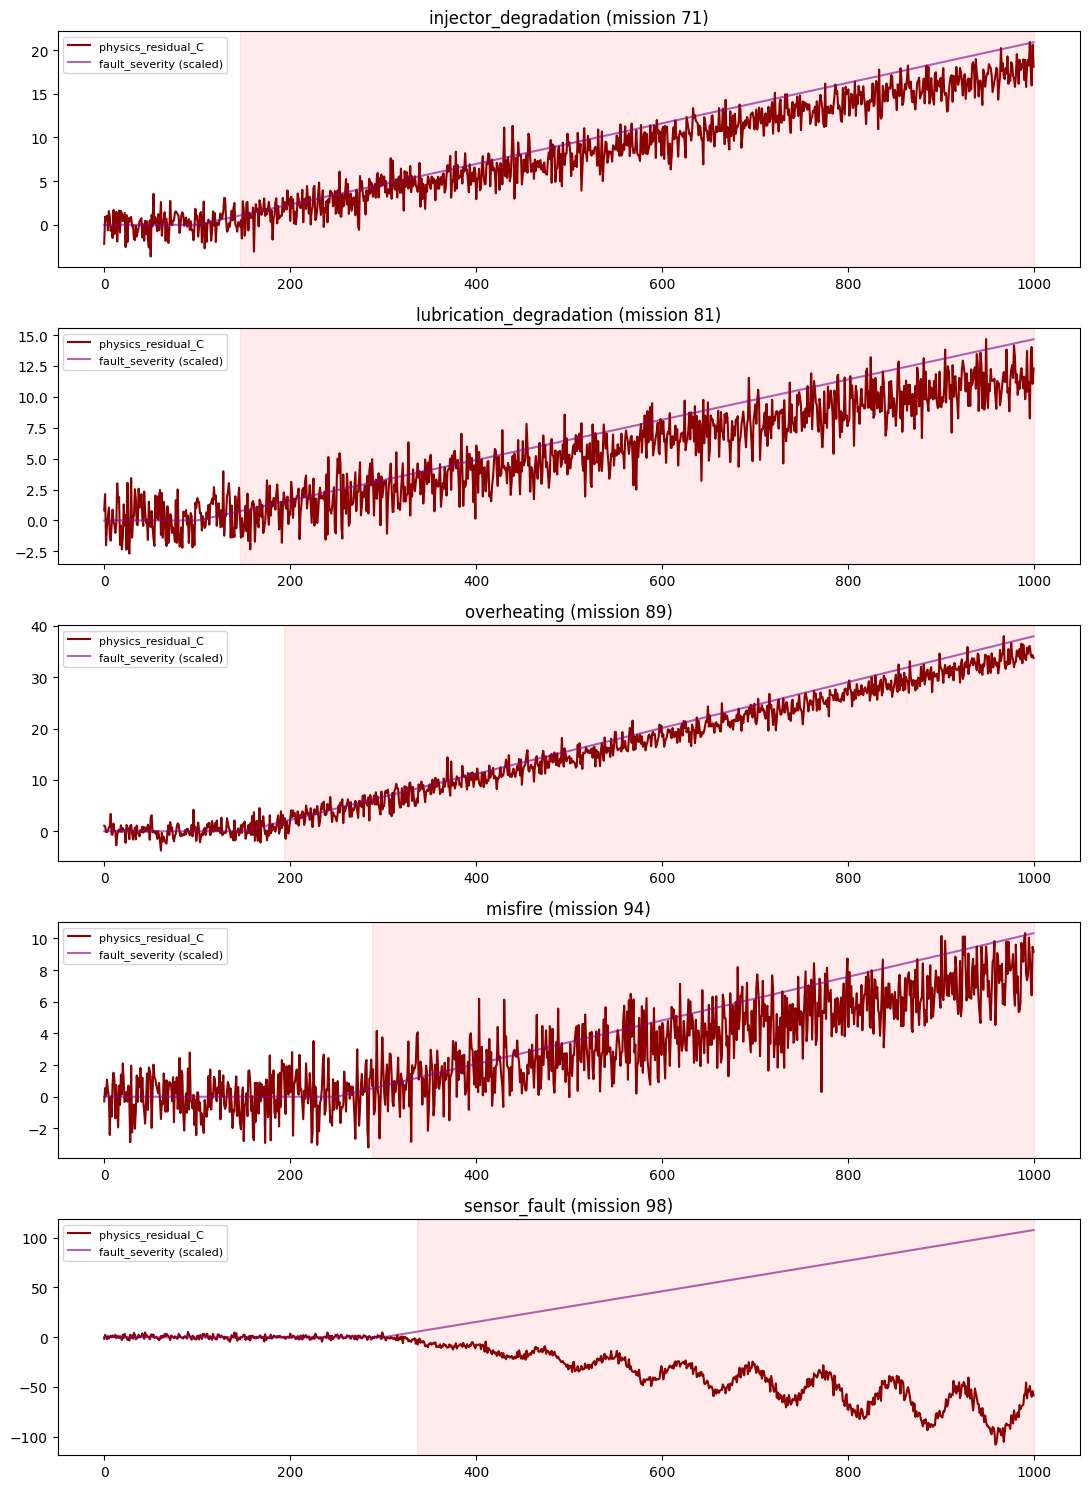

In [4]:
fault_types = ['injector_degradation', 'lubrication_degradation', 'overheating', 'misfire', 'sensor_fault']

fig, axes = plt.subplots(len(fault_types), 1, figsize=(11, 3 * len(fault_types)), sharex=False)

for ax, ft in zip(axes, fault_types):
    mission_id = df[df['mission_type'] == ft]['mission_id'].iloc[0]
    m = df[df['mission_id'] == mission_id].sort_values('timestamp_s')
    ax.plot(m['timestamp_s'], m['physics_residual_C'], label='physics_residual_C', color='darkred')
    ax.plot(m['timestamp_s'], m['fault_severity'] * m['physics_residual_C'].abs().max(),
            label='fault_severity (scaled)', color='purple', alpha=0.6)
    onset = m[m['fault_type'] != 'normal']['timestamp_s'].min()
    ax.axvspan(onset, m['timestamp_s'].max(), color='red', alpha=0.08)
    ax.set_title(f'{ft} (mission {mission_id})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 3. Feature engineering

Same core idea as the first notebook — rolling mean/std/slope over a 10-second
window per sensor, computed separately per mission so we never mix data across
missions. This dataset gives us more physics context than before, so we add:

- `cht_residual`, `egt_residual`, `rpm_residual` — actual minus physics-model-
  expected value for CHT, EGT, and RPM. These are the strongest signals in the
  whole feature set, since a physics-informed digital twin's whole point is
  spotting when reality diverges from the expected model.
- `egt_rpm_ratio`, `fuel_egt_ratio` — same efficiency-style ratios as before.

We drop `alternator_health` (constant 1.0 for every row in this dataset — zero
information) and a few label-adjacent columns (`degradation`, `health_index`,
etc.) from the feature set since those either duplicate the target or would be
unknown at prediction time in a real deployment.

In [5]:
FEATURE_BASE = ['cht_C', 'egt_C', 'oil_temperature_C', 'oil_pressure_bar',
                'fuel_flow_kg_s', 'vibration_rms', 'battery_voltage_V',
                'injection_timing_deg', 'physics_residual_C']

WINDOW = 10  # seconds, data is 1 Hz

def engineer_features(data, feature_base=FEATURE_BASE, window=WINDOW):
    pieces = []
    for mission_id, g in data.groupby('mission_id', sort=False):
        g = g.sort_values('timestamp_s').copy()
        for c in feature_base:
            g[f'{c}_roll_mean'] = g[c].rolling(window, min_periods=1).mean()
            g[f'{c}_roll_std']  = g[c].rolling(window, min_periods=1).std().fillna(0)
            g[f'{c}_slope']     = g[c].diff().rolling(window, min_periods=1).mean().fillna(0)
        g['egt_rpm_ratio']  = g['egt_C'] / g['rpm']
        g['fuel_egt_ratio'] = g['fuel_flow_kg_s'] / (g['egt_C'] + 1e-6)
        g['cht_residual']   = g['cht_C'] - g['expected_cht_C']
        g['egt_residual']   = g['egt_C'] - g['expected_egt_C']
        g['rpm_residual']   = g['rpm'] - g['expected_rpm']
        pieces.append(g)
    return pd.concat(pieces).reset_index(drop=True)

df_feat = engineer_features(df)
print(df_feat.shape)


(100000, 66)


## 4. Train/test split — by mission, stratified by fault type

With only 100 missions and some fault types as rare as 3-4 missions
(`sensor_fault`, `misfire`), we can't just randomly hold out 20% of *rows* —
that leaks (same reason as the first notebook, just more important now with
more fault types to keep separate). Instead we hold out **whole missions**,
and we do it **per mission_type** so every fault type is represented in both
train and test, even the rare ones (at least 1 full mission held out per
type).

This is a stronger, more honest split than the first notebook's — since now
the model is tested on missions it has genuinely never seen at all, not just
a later time-slice of the same mission.

In [6]:
mission_info = df_feat[['mission_id', 'mission_type']].drop_duplicates()

rng = np.random.RandomState(42)
train_missions, test_missions = [], []
for mtype, g in mission_info.groupby('mission_type'):
    ids = g['mission_id'].values.copy()
    rng.shuffle(ids)
    n_test = max(1, int(round(len(ids) * 0.2)))  # at least 1 mission held out
    test_missions += list(ids[:n_test])
    train_missions += list(ids[n_test:])

train_df = df_feat[df_feat['mission_id'].isin(train_missions)].reset_index(drop=True)
test_df  = df_feat[df_feat['mission_id'].isin(test_missions)].reset_index(drop=True)

print(f'{len(train_missions)} train missions / {len(test_missions)} test missions')
print()
print('Train fault_type counts:')
print(train_df['fault_type'].value_counts())
print()
print('Test fault_type counts:')
print(test_df['fault_type'].value_counts())


79 train missions / 21 test missions

Train fault_type counts:
fault_type
normal                     60352
injector_degradation        6832
lubrication_degradation     5124
overheating                 3228
misfire                     2136
sensor_fault                1328
Name: count, dtype: int64

Test fault_type counts:
fault_type
normal                     15401
injector_degradation        1708
lubrication_degradation     1708
overheating                  807
misfire                      712
sensor_fault                 664
Name: count, dtype: int64


In [7]:
EXCLUDE_COLS = ['timestamp_s', 'engine_id', 'mission_id', 'mission_type',
                'fault_type', 'fault_severity', 'degradation', 'failure_flag',
                'rul_hours', 'health_index', 'alternator_health']
FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE_COLS]

print(f'{len(FEATURE_COLS)} features going into the model')

le = LabelEncoder()
le.fit(df_feat['fault_type'])
print('Classes:', dict(zip(le.classes_, range(len(le.classes_)))))

y_train = le.transform(train_df['fault_type'])
y_test  = le.transform(test_df['fault_type'])
X_train, X_test = train_df[FEATURE_COLS], test_df[FEATURE_COLS]


55 features going into the model
Classes: {'injector_degradation': 0, 'lubrication_degradation': 1, 'misfire': 2, 'normal': 3, 'overheating': 4, 'sensor_fault': 5}


## 5. Multi-class XGBoost model

`objective='multi:softprob'` tells XGBoost to output a probability distribution
over all 6 classes per row (instead of a single 0/1 like the binary version in
notebook 1). `num_class` must match the number of distinct fault types +
normal.

In [8]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=6, ...)

## 6. Evaluation

Per-class precision/recall (important — a model can look great overall while
quietly failing on the rarest class), a full confusion matrix so you can see
exactly which faults get confused with which, and macro-averaged ROC-AUC
(one-vs-rest) as a single overall number.

In [9]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)

print(classification_report(y_test, pred, target_names=le.classes_, digits=3))

macro_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
print('Macro ROC-AUC (one-vs-rest):', round(macro_auc, 4))


                         precision    recall  f1-score   support

   injector_degradation      0.996     1.000     0.998      1708
lubrication_degradation      1.000     1.000     1.000      1708
                misfire      1.000     0.996     0.998       712
                 normal      1.000     1.000     1.000     15401
            overheating      1.000     0.996     0.998       807
           sensor_fault      0.995     0.998     0.997       664

               accuracy                          0.999     21000
              macro avg      0.999     0.998     0.998     21000
           weighted avg      0.999     0.999     0.999     21000

Macro ROC-AUC (one-vs-rest): 1.0


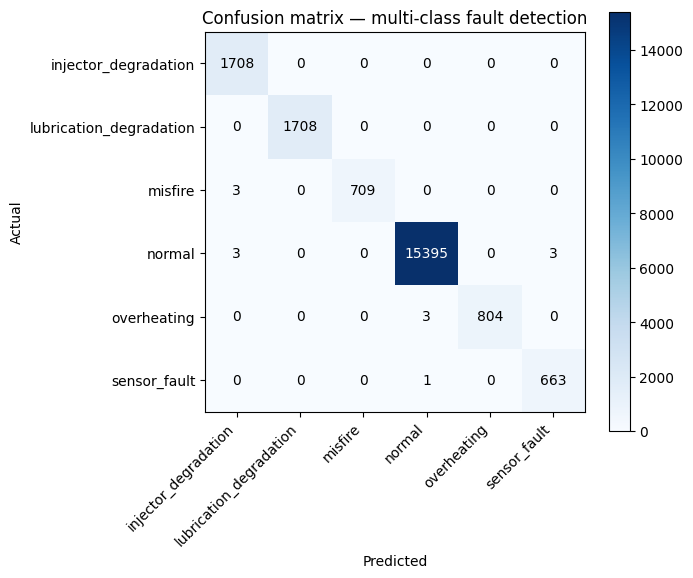

In [10]:
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — multi-class fault detection')

for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()


## 7. Explainability (SHAP)

For a multi-class model, SHAP gives a separate importance ranking per class —
this shows which features matter for identifying `overheating` vs. which
matter for `misfire`, for instance, which is exactly the kind of
interpretable diagnosis a maintenance engineer needs (and satisfies the
"Explainable AI for fault diagnosis" innovation area).

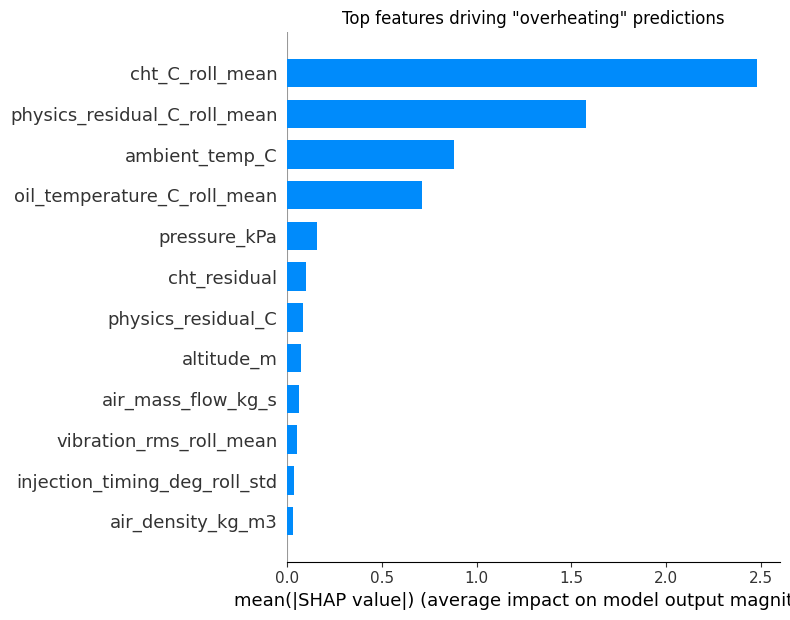

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values is a list (one array per class) for older shap versions,
# or a 3D array (rows, features, classes) for newer versions — handle both
if isinstance(shap_values, list):
    class_shap = {cls: shap_values[i] for i, cls in enumerate(le.classes_)}
else:
    class_shap = {cls: shap_values[:, :, i] for i, cls in enumerate(le.classes_)}

# Show top features for one fault type as an example
example_class = 'overheating'
shap.summary_plot(class_shap[example_class], X_test, plot_type='bar', show=False, max_display=12)
plt.title(f'Top features driving "{example_class}" predictions')
plt.tight_layout()
plt.show()


## 8. Combined fault-detection output

For every timestep: which fault (if any) is predicted, the model's confidence,
and a maintenance advisory string — this is what feeds the Health Index /
dashboard node in the overall digital twin architecture.

In [12]:
ADVISORY_MAP = {
    'normal': 'Normal — no action needed.',
    'injector_degradation': 'Injector abnormality suspected — fuel flow / EGT ratio drifting from expected. Inspect injector.',
    'lubrication_degradation': 'Oil pressure/temperature trending abnormal — inspect lubrication system.',
    'overheating': 'CHT/EGT trending above expected — check cooling airflow and mixture settings.',
    'misfire': 'Periodic RPM/EGT dropout detected — inspect ignition and fuel delivery.',
    'sensor_fault': 'Sensor reading inconsistent with physics model and cross-sensor checks — verify sensor integrity.'
}

def fault_detection_output(data, model, feature_cols, label_encoder, min_confidence=0.5):
    X = data[feature_cols]
    proba = model.predict_proba(X)
    pred_idx = proba.argmax(axis=1)
    confidence = proba.max(axis=1)
    fault_type_pred = label_encoder.inverse_transform(pred_idx)

    # below min_confidence, fall back to 'normal' rather than a shaky fault call
    fault_type_pred = np.where(confidence >= min_confidence, fault_type_pred, 'normal')

    return pd.DataFrame({
        'timestamp_s': data['timestamp_s'].values,
        'mission_id': data['mission_id'].values,
        'fault_type_pred': fault_type_pred,
        'confidence': confidence,
        'advisory': [ADVISORY_MAP[f] for f in fault_type_pred]
    })

fault_output = fault_detection_output(test_df, model, FEATURE_COLS, le)
fault_output[fault_output['fault_type_pred'] != 'normal'].head(10)


,timestamp_s,mission_id,fault_type_pred,confidence,advisory
14142,142,72,injector_degradation,0.638248,Injector abnormality suspected — fuel flow / E...
14144,144,72,injector_degradation,0.982383,Injector abnormality suspected — fuel flow / E...
14145,145,72,injector_degradation,0.992561,Injector abnormality suspected — fuel flow / E...
14146,146,72,injector_degradation,0.999961,Injector abnormality suspected — fuel flow / E...
14147,147,72,injector_degradation,0.999971,Injector abnormality suspected — fuel flow / E...
14148,148,72,injector_degradation,0.999964,Injector abnormality suspected — fuel flow / E...
14149,149,72,injector_degradation,0.999796,Injector abnormality suspected — fuel flow / E...
14150,150,72,injector_degradation,0.999936,Injector abnormality suspected — fuel flow / E...
14151,151,72,injector_degradation,0.999932,Injector abnormality suspected — fuel flow / E...
14152,152,72,injector_degradation,0.999841,Injector abnormality suspected — fuel flow / E...


## 9. Save the model, label encoder, and feature list

In [13]:
joblib.dump(model, 'fault_detection_multiclass_xgb.pkl')
joblib.dump(le, 'fault_detection_label_encoder.pkl')

with open('fault_detection_multiclass_feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('Saved: fault_detection_multiclass_xgb.pkl, fault_detection_label_encoder.pkl, fault_detection_multiclass_feature_cols.json')


Saved: fault_detection_multiclass_xgb.pkl, fault_detection_label_encoder.pkl, fault_detection_multiclass_feature_cols.json


### To reload later:
```python
import joblib, json
model = joblib.load('fault_detection_multiclass_xgb.pkl')
le = joblib.load('fault_detection_label_encoder.pkl')
with open('fault_detection_multiclass_feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
```

### Summary — how the model works, end to end
1. Raw sensor readings come in at 1 Hz per mission.
2. We compute rolling statistics (mean/std/trend) and physics-model residuals
   over a 10-second window — this turns "one noisy reading" into "a pattern
   over time," which is what actually distinguishes real faults from normal
   fluctuation.
3. XGBoost — an ensemble of decision trees trained sequentially, each one
   correcting the previous trees' mistakes — learns which feature patterns
   correspond to each of the 6 classes.
4. At inference time, the model outputs a probability for each class; we take
   the highest one (above a confidence floor) as the prediction, attach a
   plain-language advisory, and pass it downstream to the health index /
   dashboard.

This model supersedes the first (binary) fault-detection notebook — same
overall structure and design decisions (chronological/mission-level
splitting to avoid leakage, physics-residual features, SHAP explainability),
now generalized to real multi-class fault diagnosis.
